In [ ]:
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install trl datasets accelerate peft bitsandbytes transformers sentencepiece evaluate matplotlib pandas
!pip -q install tensorboard

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.8/403.8 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s 

In [ ]:
import gc
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from unsloth import FastLanguageModel

import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.profiler import ProfilerActivity


from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
    default_data_collator,
)

from trl import SFTConfig, SFTTrainer


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
import warnings
warnings.simplefilter("ignore")

### Утилиты и настройки


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def reset_cuda_peak():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


def gpu_mem_snapshot_mb():
    return {
        "allocated_mb": torch.cuda.memory_allocated() / 1024**2,
        "reserved_mb": torch.cuda.memory_reserved() / 1024**2,
        "max_allocated_mb": torch.cuda.max_memory_allocated() / 1024**2,
        "max_reserved_mb": torch.cuda.max_memory_reserved() / 1024**2,
    }


def cleanup_cuda_cpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def release_experiment_run(trainer, tokenizer=None):
    if trainer is not None:
        model = getattr(trainer, "model", None)
        try:
            trainer.model = None
        except Exception:
            pass
        del trainer

        if model is not None:
            del model

    if tokenizer is not None:
        del tokenizer

    cleanup_cuda_cpu()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

In [ ]:
MODEL_QWEN = "Qwen/Qwen3-0.6B"
MODEL_UNSLOTH_QWEN = "unsloth/Qwen3-0.6B"
DATASET_NAME = "Vikhrmodels/GrandMaster-PRO-MAX"

SEED = 42
MAX_SEQ_LENGTH = 1024
TRAIN_ROWS = 2000
EVAL_RATIO = 0.1

PER_DEVICE_BATCH_SIZE = 1
GRAD_ACC_STEPS = 8
EFFECTIVE_BATCH_SIZE = PER_DEVICE_BATCH_SIZE * GRAD_ACC_STEPS

MAX_STEPS = 12
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.05
LOGGING_STEPS = 1

PROFILE_WAIT = 1
PROFILE_WARMUP = 1
PROFILE_ACTIVE = 3
PROFILE_REPEAT = 1
PROFILE_WITH_STACK = True
STOP_AFTER_PROFILE_DEFAULT = True

BASE_LOG_DIR = Path("/content/profiler_traces")
BASE_LOG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
prompts_for_test = [
    "Как вкусно приготовить индейку на гриле?",
    "Как распознать приближающийся инсульт?",
    "Сформулируй основные каноны архитектуры древних цивилизаций",
    "Облагать ли страховыми взносами суммы прощенного долга по займу от организации, где работает застрахованный?",
    "Расскажи мне про Курчатова",
]

In [ ]:
set_seed(SEED)

In [ ]:
def print_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    ratio = 100.0 * trainable / total
    report = {"trainable": trainable, "total": total, "trainable_pct": ratio}
    print(report)
    return report


def build_lora_config():
    return LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.0,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )


def build_sft_config(output_dir, run_name, dataloader_mode="fast"):
    workers = 2 if dataloader_mode == "fast" else 0
    pin_memory = dataloader_mode == "fast"
    persistent_workers = dataloader_mode == "fast"

    return SFTConfig(
        output_dir=output_dir,
        run_name=run_name,
        per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACC_STEPS,
        max_steps=MAX_STEPS,
        learning_rate=LEARNING_RATE,
        warmup_steps=max(1, int(MAX_STEPS * WARMUP_RATIO)),
        logging_steps=LOGGING_STEPS,
        save_strategy="no",
        eval_strategy="no",
        report_to="none",
        optim="paged_adamw_8bit",
        dataset_text_field="text",
        max_length=MAX_SEQ_LENGTH,
        packing=True,
        dataloader_num_workers=workers,
        dataloader_pin_memory=pin_memory,
        dataloader_persistent_workers=persistent_workers,
        seed=SEED,
    )


In [ ]:
def make_slow_collator(enable_slowdown):
    #Имитируем CPU bottleneck в input pipeline на этапе коллации батча.

    def collate(features):
        if enable_slowdown:
            _ = 0
            for f in features:
                ids = f.get("input_ids", [])
                for v in ids[:128]:
                    _ += int(v) % 7
            time.sleep(0.5)

        batch = default_data_collator(features)

        if "labels" not in batch and "input_ids" in batch:
            batch["labels"] = batch["input_ids"].clone()

        if "attention_mask" not in batch and "input_ids" in batch:
            batch["attention_mask"] = torch.ones_like(batch["input_ids"], dtype=torch.long)

        return batch

    return collate


In [ ]:
ds = load_dataset(DATASET_NAME)
raw = ds["train"].shuffle(seed=SEED).select(range(min(TRAIN_ROWS, len(ds["train"]))))
raw

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/139M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/122M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/5.85M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/151822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3291 [00:00<?, ? examples/s]

Dataset({
    features: ['source', 'conversation', 'prompt_tokens', 'answer_tokens', 'cluster', 'prompt_lang', 'answer_lang'],
    num_rows: 2000
})

In [ ]:
def to_messages(example):
    conversation = example.get("conversation", [])
    if not isinstance(conversation, list):
        conversation = [conversation]

    user = next(
        (m.get("content", "") for m in conversation if isinstance(m, dict) and m.get("role") == "user"),
        "",
    )
    assistant = next(
        (m.get("content", "") for m in conversation if isinstance(m, dict) and m.get("role") == "assistant"),
        "",
    )

    return [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент."},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]


### Подготовка датасета


In [ ]:
def build_tokenizer(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer


def apply_qwen_chat_template(tokenizer, messages, add_generation_prompt):
    """Qwen3: без enable_thinking=False модель уходит в блок </think> и генерирует мусор."""
    kwargs = {"tokenize": False, "add_generation_prompt": add_generation_prompt}
    try:
        return tokenizer.apply_chat_template(messages, **kwargs, enable_thinking=False)
    except TypeError:
        return tokenizer.apply_chat_template(messages, **kwargs)


In [ ]:
tokenizer_for_data = build_tokenizer(MODEL_QWEN)

def format_text(example):
    messages = to_messages(example)
    text = apply_qwen_chat_template(tokenizer_for_data, messages, add_generation_prompt=False)
    return {"text": text}

processed = raw.map(format_text, remove_columns=raw.column_names)
dataset = processed.train_test_split(test_size=EVAL_RATIO, seed=SEED)
dataset


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1800
    })
    test: Dataset({
        features: ['text'],
        num_rows: 200
    })
})

### ProfilerCallback

In [ ]:
class ProfilerCallback(TrainerCallback):
    def __init__(
        self,
        trace_dir,
        stop_after_profile=True,
        with_stack=True,
        wait=PROFILE_WAIT,
        warmup=PROFILE_WARMUP,
        active=PROFILE_ACTIVE,
        repeat=PROFILE_REPEAT,
    ):
        self.trace_dir = trace_dir
        self.stop_after_profile = stop_after_profile
        self.with_stack = with_stack
        self.wait = wait
        self.warmup = warmup
        self.active = active
        self.repeat = repeat

        self.prof = None
        self.closed = False
        self.steps_seen = 0
        self.profile_total_steps = (wait + warmup + active) * repeat

    def on_train_begin(self, args, state, control, **kwargs):
        os.makedirs(self.trace_dir, exist_ok=True)
        self.prof = torch.profiler.profile(
            activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
            schedule=torch.profiler.schedule(
                wait=self.wait,
                warmup=self.warmup,
                active=self.active,
                repeat=self.repeat,
            ),
            on_trace_ready=torch.profiler.tensorboard_trace_handler(self.trace_dir),
            record_shapes=True,
            profile_memory=True,
            with_stack=self.with_stack,
        )
        self.prof.__enter__()

    def _safe_close(self):
        if self.prof is not None and not self.closed:
            self.prof.__exit__(None, None, None)
            self.closed = True

    def on_step_end(self, args, state, control, **kwargs):
        if self.prof is None:
            return control

        self.prof.step()
        self.steps_seen += 1

        if self.stop_after_profile and self.steps_seen >= self.profile_total_steps:
            control.should_training_stop = True

        return control

    def on_train_end(self, args, state, control, **kwargs):
        self._safe_close()

    def get_key_averages(self):
        if self.prof is None:
            return None
        return self.prof.key_averages()


In [ ]:
def get_top_ops(key_avg, sort_by, top_k=10):
    rows = []
    for evt in key_avg:
        rows.append(
            {
                "name": evt.key,
                "self_cpu_time_total": float(getattr(evt, "self_cpu_time_total", 0.0)),
                "self_cuda_time_total": float(getattr(evt, "self_cuda_time_total", 0.0)),
                "cpu_time_total": float(getattr(evt, "cpu_time_total", 0.0)),
                "cuda_time_total": float(getattr(evt, "cuda_time_total", 0.0)),
                "count": int(getattr(evt, "count", 0)),
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(sort_by, ascending=False).head(top_k).reset_index(drop=True)


def estimate_tokens_per_sample(dataset_split, tokenizer, n_samples=64):
    sample_n = min(n_samples, len(dataset_split))
    subset = dataset_split.select(range(sample_n))
    lengths = []
    for txt in subset["text"]:
        lengths.append(len(tokenizer(txt, add_special_tokens=False)["input_ids"]))
    return float(np.mean(lengths)) if lengths else 0.0


### Готовим модель

In [ ]:
def prepare_model_tokenizer_peft(mode):
    """mode: lora_fp16 | qlora_qwen | qlora_unsloth"""
    lora_cfg = build_lora_config()

    if mode == "lora_fp16":
        tokenizer = build_tokenizer(MODEL_QWEN)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_QWEN,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
        )
        model = get_peft_model(model, lora_cfg)
        return model, tokenizer

    if mode == "qlora_qwen":
        tokenizer = build_tokenizer(MODEL_QWEN)
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_QWEN,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
        model = prepare_model_for_kbit_training(model)
        model = get_peft_model(model, lora_cfg)
        return model, tokenizer

    if mode == "qlora_unsloth":
       model, tokenizer = FastLanguageModel.from_pretrained(
          model_name=MODEL_UNSLOTH_QWEN,
          max_seq_length=MAX_SEQ_LENGTH,
          load_in_4bit=True,
          dtype=None,
       )
       model = FastLanguageModel.get_peft_model(
          model,
          r=16,
          lora_alpha=32,
          lora_dropout=0.0,
          bias="none",
          target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
          use_gradient_checkpointing="unsloth",
       )
       tokenizer.padding_side = "right"
       return model, tokenizer


In [ ]:
def prepare_model_for_generation(model, mode=''):
    model.eval()

    if hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()

    if hasattr(model, "config"):
        model.config.use_cache = False

    if mode == "unsloth":
        FastLanguageModel.for_inference(model)


def generate_chat(model, tokenizer, user_text, max_new_tokens=180, mode=''):
    messages = [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент."},
        {"role": "user", "content": user_text},
    ]
    prompt = apply_qwen_chat_template(tokenizer, messages, add_generation_prompt=True)

    prepare_model_for_generation(model, mode)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id,
        max_new_tokens=max_new_tokens,
        use_cache=False,
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)


### Код запуска экспериментов

In [ ]:
def run_experiment(
    experiment_name,
    model_id,
    finetune_mode,
    use_slow_pipeline,
    stop_after_profile=STOP_AFTER_PROFILE_DEFAULT,
):
    gc.collect()
    reset_cuda_peak()

    model, tokenizer = prepare_model_tokenizer_peft(finetune_mode)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
    tokenizer.eos_token_id = tokenizer.convert_tokens_to_ids(tokenizer.eos_token)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id

    trainable_report = print_trainable_params(model)

    trace_dir = str(BASE_LOG_DIR / experiment_name)
    profiler_cb = ProfilerCallback(
        trace_dir=trace_dir,
        stop_after_profile=stop_after_profile,
        with_stack=PROFILE_WITH_STACK,
    )

    dataloader_mode = "slow" if use_slow_pipeline else "fast"
    run_dir = f"/content/sft_runs/{experiment_name}"


    args = build_sft_config(
        output_dir=run_dir,
        run_name=experiment_name,
        dataloader_mode=dataloader_mode,
    )
    args.eos_token = tokenizer.eos_token
    args.pad_token = tokenizer.pad_token

    data_collator = make_slow_collator(enable_slowdown=use_slow_pipeline)

    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        train_dataset=dataset["train"],
        eval_dataset=dataset["test"],
        data_collator=data_collator,
        args=args,
    )
    trainer.add_callback(profiler_cb)

    avg_tokens = estimate_tokens_per_sample(dataset["train"], tokenizer)

    torch.cuda.synchronize()
    cleanup_cuda_cpu()
    reset_cuda_peak()

    start = time.perf_counter()
    trainer.train()
    torch.cuda.synchronize()
    end = time.perf_counter()

    elapsed = end - start
    steps_done = max(1, int(trainer.state.global_step))
    active_steps = max(1, steps_done - PROFILE_WAIT)
    steps_per_sec = active_steps / elapsed
    samples_per_sec = steps_per_sec * EFFECTIVE_BATCH_SIZE
    tokens_per_sec = samples_per_sec * avg_tokens

    mem = gpu_mem_snapshot_mb()

    key_avg = profiler_cb.get_key_averages()
    top_cuda = get_top_ops(key_avg, "self_cuda_time_total", top_k=10)
    top_cpu = get_top_ops(key_avg, "self_cpu_time_total", top_k=10)

    result = {
        "experiment_name": experiment_name,
        "model_id": model_id,
        "finetune_mode": finetune_mode,
        "intentional_bottleneck": "yes" if use_slow_pipeline else "no",
        "wall_clock_sec": elapsed,
        "steps_per_sec": steps_per_sec,
        "samples_per_sec": samples_per_sec,
        "approx_tokens_per_sec": tokens_per_sec,
        "peak_gpu_mem_mb": mem["max_allocated_mb"],
        "peak_gpu_reserved_mb": mem["max_reserved_mb"],
        "top_cuda_op": top_cuda.iloc[0]["name"] if len(top_cuda) else "n/a",
        "top_cpu_op": top_cpu.iloc[0]["name"] if len(top_cpu) else "n/a",
        "trainer_args": args.to_dict(),
        "trainable_params": trainable_report,
        "trace_dir": trace_dir,
        "top_cuda_table": top_cuda,
        "top_cpu_table": top_cpu,
    }

    cleanup_cuda_cpu()
    print(f"tensorboard --logdir {trace_dir}")
    return trainer, tokenizer, result


### Сценарий A - LoRA FP16 без квантования

In [ ]:
trainer_a, tokenizer_a, result_a = run_experiment(
    experiment_name="A_lora_fp16_no_quant",
    model_id=MODEL_QWEN,
    finetune_mode="lora_fp16",
    use_slow_pipeline=False,
)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
1,1.906196
2,2.274566
3,1.838945
4,1.929815
5,1.520015


tensorboard --logdir /content/profiler_traces/A_lora_fp16_no_quant


In [ ]:
display(pd.DataFrame([{
    "trainable_params": result_a["trainable_params"]["trainable"],
    "trainable_pct": result_a["trainable_params"]["trainable_pct"],
    "peak_gpu_mem_mb": result_a["peak_gpu_mem_mb"],
    "peak_gpu_reserved_mb": result_a["peak_gpu_reserved_mb"],
    "steps_per_sec": result_a["steps_per_sec"],
    "samples_per_sec": result_a["samples_per_sec"],
    "approx_tokens_per_sec": result_a["approx_tokens_per_sec"],
    "top_cuda_op": result_a["top_cuda_op"],
    "top_cpu_op": result_a["top_cpu_op"],
}]))

,trainable_params,trainable_pct,peak_gpu_mem_mb,peak_gpu_reserved_mb,steps_per_sec,samples_per_sec,approx_tokens_per_sec,top_cuda_op,top_cpu_op
0,4587520,0.606638,3336.046875,3404.0,0.040325,0.322602,243.912529,void cutlass::Kernel2<cutlass_80_tensorop_f16_...,ProfilerStep*


In [ ]:
result_a["top_cuda_table"].head(5)

,name,self_cpu_time_total,self_cuda_time_total,cpu_time_total,cuda_time_total,count
0,void cutlass::Kernel2<cutlass_80_tensorop_f16_...,0.000000e+00,0.0,0.000000e+00,0.0,1
1,ProfilerStep*,1.614664e+07,0.0,2.049769e+07,0.0,3
2,aten::mean,1.301760e+05,0.0,1.787778e+05,0.0,5403
3,aten::as_strided,1.480318e+05,0.0,1.480318e+05,0.0,92366
4,cudaLaunchKernel,1.982901e+06,0.0,1.991068e+06,0.0,203775


In [ ]:
for prompt in prompts_for_test:
    print(generate_chat(trainer_a.model, tokenizer_a, prompt))

release_experiment_run(trainer_a, tokenizer_a)
trainer_a = tokenizer_a = None

system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
<think>

</think>

Вкусный индейка на гриле требует внимательного подхода к подготовке, уходу и приготовлению. Вот шаги по приготовлению:

1. **Подготовка индейки**:
   - Сушите индейку до сухости. Нужно сушить ее по 20–30 минут в духовке или поджарить ее на огне. Это ускорит процесс уборки и уменьшит ее вкус.
   - Приготовьте немного крахмальной воды или пастеризованную воду для усвоения ореховых масел. Это поможет индейке сохранить вкус и вкусовые особенности.

2. **Подготовка гриль**:
   - Пространством между индейкой и
system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
<think>

</think>

При приближении инсуляции или инсульта, возможно, вы можете заметить следующие изменения:

1. **Симптомы инсульта:**
   - Спазмы и тремор в области головы, лица и шеи.
   - Замедленное сознание или потеря сознания.
   - Непроизвольные мышечные тachyc

### Сценарий B - QLoRA на Qwen

In [ ]:
trainer_b, tokenizer_b, result_b = run_experiment(
    experiment_name="B_qlora_qwen",
    model_id=MODEL_QWEN,
    finetune_mode="qlora_qwen",
    use_slow_pipeline=False,
)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


{'trainable': 4587520, 'total': 536018944, 'trainable_pct': 0.8558503484533562}
Unsloth: Sample packing skipped (custom data collator detected).


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
1,2.035684
2,2.431509
3,1.944251
4,2.044513
5,1.648551


tensorboard --logdir /content/profiler_traces/B_qlora_qwen


In [ ]:
display(pd.DataFrame([{
    "trainable_params": result_b["trainable_params"]["trainable"],
    "trainable_pct": result_b["trainable_params"]["trainable_pct"],
    "peak_gpu_mem_mb": result_b["peak_gpu_mem_mb"],
    "peak_gpu_reserved_mb": result_b["peak_gpu_reserved_mb"],
    "steps_per_sec": result_b["steps_per_sec"],
    "samples_per_sec": result_b["samples_per_sec"],
    "approx_tokens_per_sec": result_b["approx_tokens_per_sec"],
    "top_cuda_op": result_b["top_cuda_op"],
    "top_cpu_op": result_b["top_cpu_op"],
}]))

,trainable_params,trainable_pct,peak_gpu_mem_mb,peak_gpu_reserved_mb,steps_per_sec,samples_per_sec,approx_tokens_per_sec,top_cuda_op,top_cpu_op
0,4587520,0.85585,3956.739746,4328.0,0.028184,0.22547,170.472634,void cutlass::Kernel2<cutlass_80_tensorop_bf16...,ProfilerStep*


In [ ]:
for prompt in prompts_for_test:
    print(generate_chat(trainer_b.model, tokenizer_b, prompt))

release_experiment_run(trainer_b, tokenizer_b)
trainer_b = tokenizer_b = None

system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
<think>

</think>

Вкусная индейка с грилей – это не просто приправа, а деликатессы, которая станет вашим любимым блюском. Вот простой и вкусный способ приготовить индейку на гриле:

### 1. **Приготовление индейки**
- В холодном чайнике уварить костку.
- Добавить немного соли и табака, чтобы индейка остыла и стала более прозралящей.
- Остовите индейку и выжмите её до тонкого слоя, чтобы она была мягкой и прозраляющей.

### 2. **Приготовление на гриле**
- Выжмите индейку из стекла.
- Снимите с косточки
system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
<think>

</think>

Приближение инсульта может быть описано следующими признаками и симптомами, которые могут подтверждить его:

1. **Головные боли**:
   - Инсульт может быть связан с неправильным глотанием или диссоноргией, которая может вызывать головную боль.
   - Симптомы, такие как симп

### Сценарий C - QLoRA на Unsloth с намеренным bottleneck

В этом эксперименте bottleneck создан специально, чтобы в профайлере были явно видны признаки CPU/data-bound режима

In [ ]:
# Здесь специально замедляем CPU/data pipeline

In [ ]:
trainer_c, tokenizer_c, result_c = run_experiment(
    experiment_name="C_qlora_unsloth_with_bottleneck",
    model_id=MODEL_UNSLOTH_QWEN,
    finetune_mode="qlora_unsloth",
    use_slow_pipeline=True,
)

==((====))==  Unsloth 2026.3.18: Fast Qwen3 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,800 | Num Epochs = 1 | Total steps = 12
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)


Step,Training Loss
1,2.003704
2,2.396346
3,1.934770
4,2.032237
5,1.627511


tensorboard --logdir /content/profiler_traces/C_qlora_unsloth_with_bottleneck


In [ ]:
display(pd.DataFrame([{
    "trainable_params": result_c["trainable_params"]["trainable"],
    "trainable_pct": result_c["trainable_params"]["trainable_pct"],
    "peak_gpu_mem_mb": result_c["peak_gpu_mem_mb"],
    "peak_gpu_reserved_mb": result_c["peak_gpu_reserved_mb"],
    "steps_per_sec": result_c["steps_per_sec"],
    "samples_per_sec": result_c["samples_per_sec"],
    "approx_tokens_per_sec": result_c["approx_tokens_per_sec"],
    "top_cuda_op": result_c["top_cuda_op"],
    "top_cpu_op": result_c["top_cpu_op"],
}]))

,trainable_params,trainable_pct,peak_gpu_mem_mb,peak_gpu_reserved_mb,steps_per_sec,samples_per_sec,approx_tokens_per_sec,top_cuda_op,top_cpu_op
0,4587520,1.16725,2181.85498,2262.0,0.037455,0.29964,226.550961,ProfilerStep*,ProfilerStep*


Какие признаки bottleneck искать после сценария C

Проверьте trace: большие gaps между шагами, простои GPU и доминирование CPU времени в operator view.

In [ ]:
for prompt in prompts_for_test:
    print(generate_chat(trainer_c.model, tokenizer_c, prompt, mode='unsloth'))

release_experiment_run(trainer_c, tokenizer_c)
trainer_c = tokenizer_c = None

Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
<think>

</think>

Индейка — это тонкое, кустарное овоще, с зеленой корой и пахло растительным, иногда с мятной, немного сухой мякотью. Приготовление индейки на гриле можно сделать очень вкусно. Вот как это сделать:

### 1. **Очистка и подготовка**
- Снимите индейку и убедитесь, что она была охлаждена до 60-70°C.
- Накажьте ее по небольшому количеству воды, чтобы она выдержало на гриле.
- Убедитесь, что индейка не содержит молочного или кислотного вещества (например, из морковки или томатов), так как это


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
<think>

</think>

При приближении инсуляции у людей, особенно в ранних стадиях, может возникнуть следующие симптомы:

1. **Симптомы нарушения слуха**: 
   - Повышение слуха, сильнее обычного.
   - Нарушение слуха (например, насыщение или ощущение звука, но без явного нарушения слуха).

2. **Симптомы неправильно установленной слухи**:
   - Слишком высокая степень слуха.
   - Уменьшение слуха.

3. **Симптомы нарушения зрения**:
   - Ослабление зрения.
   - Нарушение зрения или ощущение


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Сформулируй основные каноны архитектуры древних цивилизаций
assistant
<think>

</think>

Основные каноны архитектуры древних цивилизаций включают следующие аспекты:

1. **Эстетичная и мораль**:
   - Академия, субъекты, творчество, культурное и образование играют важную роль в организации общественных и индустриальных систем.

2. **Культурные и социальные особенности**:
   - Составление общественного тела требует умения управлять эмоциями, структурированными и неструктурированными формами человеческой деятельности.

3. **Использование материалов**:
   - Важность использования натуральных и искусственных материалов в разных сферах, обеспечивая их


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Облагать ли страховыми взносами суммы прощенного долга по займу от организации, где работает застрахованный?
assistant
<think>

</think>

При посредничестве между государственными и частными организациями, как и в любой другой форме, возникает вопрос о том, что застрахованный процент при подавании заявки на снятие обязательств может быть оплачен, если он был оплачен на условиях договора с поставщиком. Поэтому, чтобы убедиться, что вы получите сумму, нужно проверить:

- Сумма пострадавших средств, указанная в документе;
- Срок снятия, указанный в договоре;
- Стационарные условия по оплате;

В связи с этим, возможно, вам нужно уточнить с финансовой стороны, чтобы понять, какие условия существуют, и как их соблюсти. Если у вас есть конкретные цифры или условия,
system
Ты — полезный русскоязычный ассистент.
user
Расскажи мне про Курчатова
assistant
<think>

</think>

Курчатова — это имя человека. Основные моменты, что мы можем упомянуть о 

### Сценарий D - QLoRA на Unsloth без bottleneck

In [ ]:
trainer_d, tokenizer_d, result_d = run_experiment(
    experiment_name="D_qlora_unsloth_no_bottleneck",
    model_id=MODEL_UNSLOTH_QWEN,
    finetune_mode="qlora_unsloth",
    use_slow_pipeline=False,
)

==((====))==  Unsloth 2026.3.18: Fast Qwen3 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
{'trainable': 4587520, 'total': 393019392, 'trainable_pct': 1.167250291812573}
Unsloth: Sample packing skipped (custom data collator detected).


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,800 | Num Epochs = 1 | Total steps = 12
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)


Step,Training Loss
1,2.003704
2,2.396346
3,1.935313
4,2.033995
5,1.627727


tensorboard --logdir /content/profiler_traces/D_qlora_unsloth_no_bottleneck


In [ ]:
display(pd.DataFrame([{
    "trainable_params": result_d["trainable_params"]["trainable"],
    "trainable_pct": result_d["trainable_params"]["trainable_pct"],
    "peak_gpu_mem_mb": result_d["peak_gpu_mem_mb"],
    "peak_gpu_reserved_mb": result_d["peak_gpu_reserved_mb"],
    "steps_per_sec": result_d["steps_per_sec"],
    "samples_per_sec": result_d["samples_per_sec"],
    "approx_tokens_per_sec": result_d["approx_tokens_per_sec"],
    "top_cuda_op": result_d["top_cuda_op"],
    "top_cpu_op": result_d["top_cpu_op"],
}]))

,trainable_params,trainable_pct,peak_gpu_mem_mb,peak_gpu_reserved_mb,steps_per_sec,samples_per_sec,approx_tokens_per_sec,top_cuda_op,top_cpu_op
0,4587520,1.16725,2478.60498,2562.0,0.040671,0.325365,246.001354,ProfilerStep*,ProfilerStep*


In [ ]:
for prompt in prompts_for_test:
    print(generate_chat(trainer_d.model, tokenizer_d, prompt))

release_experiment_run(trainer_d, tokenizer_d)
trainer_d = tokenizer_d = None

Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
<think>

</think>

Вкусная индейка с грилей — это не просто вкусная салат, но и настоящая салата, которая питает и вкусна. Вот как её приготовить:

### Индейка на гриле:
1. **Подготовка индейки**: Следует выбрать индейку с тонким, сухим и зелёным стеблем. Надо убрать ветки, убедиться, что индейка чистая и без остатков. Приготовить индейку из молока, подавляя её в блендере или в кипятке. Важно убрать ветки, чтобы уменьшить нектарное содержание.

2. **Подготовка салата**: 
   - Сл


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
<think>

</think>

При приближении инсуляции, как правило, это может быть связано с несколькими факторами, но не всегда сразу. В первые дни инсуляции, например, при неправильной гормональной фазе, возможно, не будет очевидно. При приближении инсуляции, как и при любом событии, может происходить на фоне тяжелого состояния, например, сопутствующих заболеваний, включая сопутствующие болезни. Но не всегда будет появляться явное признаки. Поэтому в таком случае стоит обратиться к врачу, чтобы оценить состояние.

Если вы не знаете, как приближаться к инсулиции, то лучше всего


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Сформулируй основные каноны архитектуры древних цивилизаций
assistant
<think>

</think>

Основные каноны архитектуры древних цивилизаций включают следующие аспекты:

1. **Эстетичная и мораль**:
   - Академия, субъекты, грамотность и символы важны для архитектора.
   - Строение должно соответствовать высшим идеям, подчеркивая важность духовности.

2. **Классические структуры**:
   - Цельные, укрепленные и тайные структуры.
   - Монолитные, с возможностью роста и разворота.

3. **Использование материалов**:
   - Использование натуральных материалов для сохранения исторического стиля.
   -


Both `max_new_tokens` (=180) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
Ты — полезный русскоязычный ассистент.
user
Облагать ли страховыми взносами суммы прощенного долга по займу от организации, где работает застрахованный?
assistant
<think>

</think>

При посредничестве между государственными и частными организациями, как и в любой другой форме, возникает вопрос о том, что застрахованный процент при подавании заявки на снятие обязательств может быть оплачен, если он был оплачен на условиях договора с поставщиком. Поэтому, чтобы убедиться, что вы получите сумму, нужно проверить:

- Сумма постороннего взноса;
- Требования, по которым будет оплаченый взнос;
- Заявление, по которым вы получите деньги.

Если вы хотите, чтобы вы могли оформить заявку на снятие обязательства по итогу этого процесса, то можно использовать официальный сайт вашей организации или обратитесь к их менеджеру по кредит
system
Ты — полезный русскоязычный ассистент.
user
Расскажи мне про Курчатова
assistant
<think>

</think>

Курчатова — это имя человека. Основные моменты, что нуж

### Общие результаты

In [ ]:
all_results = [result_a, result_b, result_c, result_d]


summary_df = pd.DataFrame(
    [
        {
            "experiment_name": r["experiment_name"],
            "model_id": r["model_id"],
            "finetune_mode": r["finetune_mode"],
            "intentional_bottleneck": r["intentional_bottleneck"],
            "steps_per_sec": r["steps_per_sec"],
            "samples_per_sec": r["samples_per_sec"],
            "approx_tokens_per_sec": r["approx_tokens_per_sec"],
            "peak_gpu_mem_mb": r["peak_gpu_mem_mb"],
            "top_cuda_op": r["top_cuda_op"],
            "top_cpu_op": r["top_cpu_op"],
            "trace_dir": r["trace_dir"],
        }
        for r in all_results
    ]
)

summary_df

,experiment_name,model_id,finetune_mode,intentional_bottleneck,steps_per_sec,samples_per_sec,approx_tokens_per_sec,peak_gpu_mem_mb,top_cuda_op,top_cpu_op,trace_dir
0,A_lora_fp16_no_quant,Qwen/Qwen3-0.6B,lora_fp16,no,0.040325,0.322602,243.912529,3336.046875,void cutlass::Kernel2<cutlass_80_tensorop_f16_...,ProfilerStep*,/content/profiler_traces/A_lora_fp16_no_quant
1,B_qlora_qwen,Qwen/Qwen3-0.6B,qlora_qwen,no,0.028184,0.225470,170.472634,3956.739746,void cutlass::Kernel2<cutlass_80_tensorop_bf16...,ProfilerStep*,/content/profiler_traces/B_qlora_qwen
2,C_qlora_unsloth_with_bottleneck,unsloth/Qwen3-0.6B,qlora_unsloth,yes,0.037455,0.299640,226.550961,2181.854980,ProfilerStep*,ProfilerStep*,/content/profiler_traces/C_qlora_unsloth_with_...
3,D_qlora_unsloth_no_bottleneck,unsloth/Qwen3-0.6B,qlora_unsloth,no,0.040671,0.325365,246.001354,2478.604980,ProfilerStep*,ProfilerStep*,/content/profiler_traces/D_qlora_unsloth_no_bo...


In [ ]:
%load_ext tensorboard
%tensorboard --logdir profiler_traces/

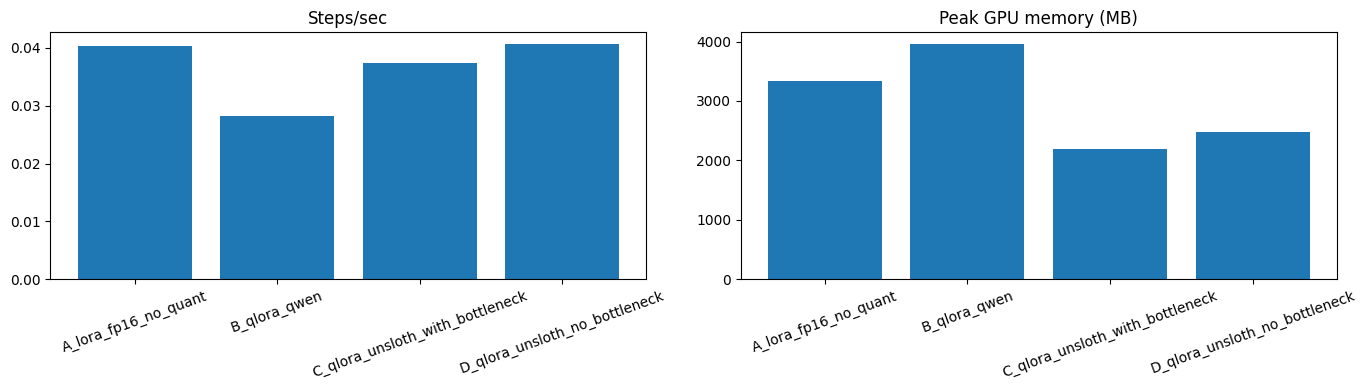

In [ ]:
plot_df = summary_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(plot_df["experiment_name"], plot_df["steps_per_sec"])
axes[0].set_title("Steps/sec")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_df["experiment_name"], plot_df["peak_gpu_mem_mb"])
axes[1].set_title("Peak GPU memory (MB)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

cleanup_cuda_cpu()
